In [176]:
# Импорты
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [177]:
# Загрузка датасета и проверка на пропуски
dataset = sklearn.datasets.fetch_california_housing(as_frame=True)
dataframe = dataset.frame
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [178]:
# Целевая переменная и признаки
y = dataframe['MedHouseVal']
X = dataframe.drop('MedHouseVal', axis=1)

# Разбивка на обучающее и тестовое множества
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [179]:
# Функция для построения модели линейной регрессии
def fit_model(X_train, y_train, X_test, y_test, model = LinearRegression(),):

  model.fit(X_train, y_train)
  # Прогнозирование на обучающем и тестовом множествах
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  # Метрики для обучающего множества
  mse_train = mean_squared_error(y_train, y_train_pred)
  rmse_train = np.sqrt(mse_train)
  r2_train = r2_score(y_train, y_train_pred)
  # Метрики для тестового множества
  mse_test = mean_squared_error(y_test, y_test_pred)
  rmse_test = np.sqrt(mse_test)
  r2_test = r2_score(y_test, y_test_pred)

  print("Метрики на обучающем множестве:")
  print(f"  MSE: {mse_train:.2f}")
  print(f"  RMSE: {rmse_train:.2f}")
  print(f"  R2: {r2_train:.2f}")
  print("\nМетрики на тестовом множестве:")
  print(f"  MSE: {mse_test:.2f}")
  print(f"  RMSE: {rmse_test:.2f}")
  print(f"  R2: {r2_test:.2f}")
  return model

first_model = fit_model(X_train, y_train, X_test, y_test)

Метрики на обучающем множестве:
  MSE: 0.52
  RMSE: 0.72
  R2: 0.61

Метрики на тестовом множестве:
  MSE: 0.56
  RMSE: 0.75
  R2: 0.58


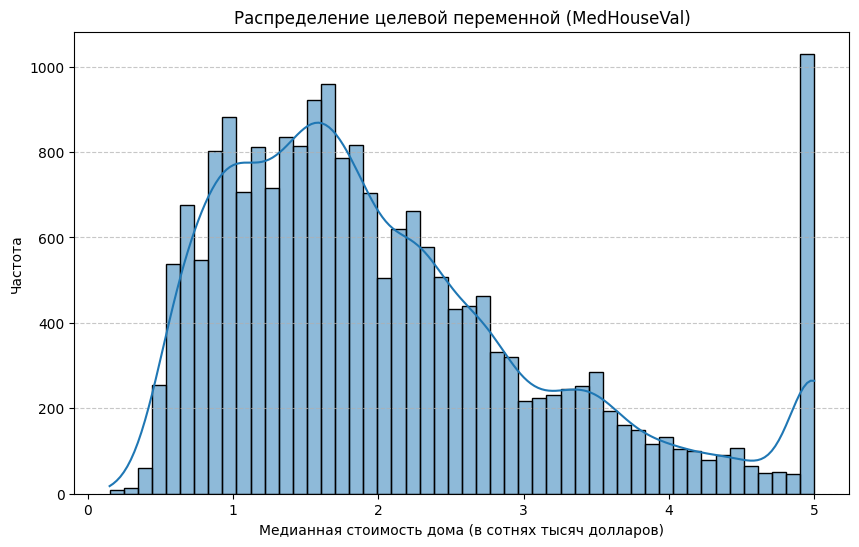

In [180]:
# Гистограмма распределения целевой переменной
plt.figure(figsize=(10, 6))
sns.histplot(y, kde=True, bins=50)
plt.title('Распределение целевой переменной (MedHouseVal)')
plt.xlabel('Медианная стоимость дома (в сотнях тысяч долларов)')
plt.ylabel('Частота')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

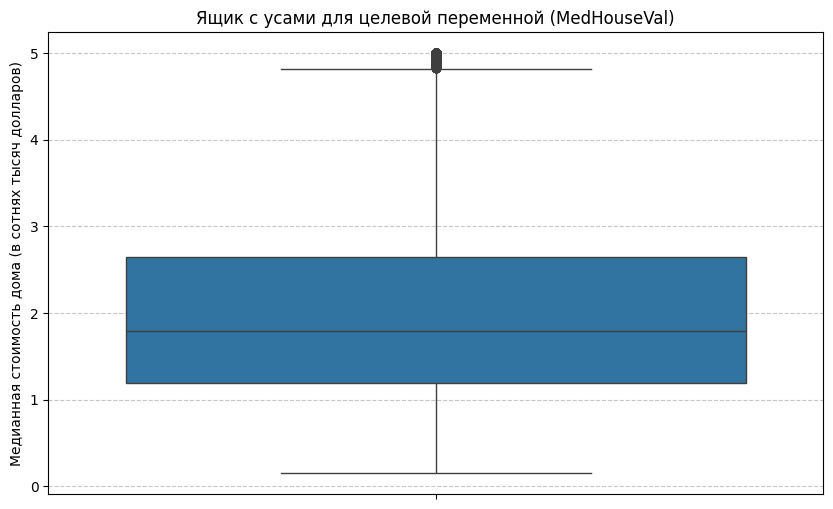

In [181]:
# Функция для ящика с усами (Box plot) для выявления выбросов
def boxplot(y):
  plt.figure(figsize=(10, 6))
  sns.boxplot(y=y)
  plt.title('Ящик с усами для целевой переменной (MedHouseVal)')
  plt.ylabel('Медианная стоимость дома (в сотнях тысяч долларов)')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()
  return

boxplot(y)

### Вывод по распределению целевой переменной:

*   **Гистограмма** показывает, что распределение медианной стоимости домов имеет правостороннюю асимметрию, то есть больше домов с меньшей стоимостью, и длинный хвост в сторону высоких значений.
*   **Ящик с усами (Box plot)** показывает наличие **выбросов** в верхней части распределения. Эти точки представляют дома с очень высокой медианной стоимостью.

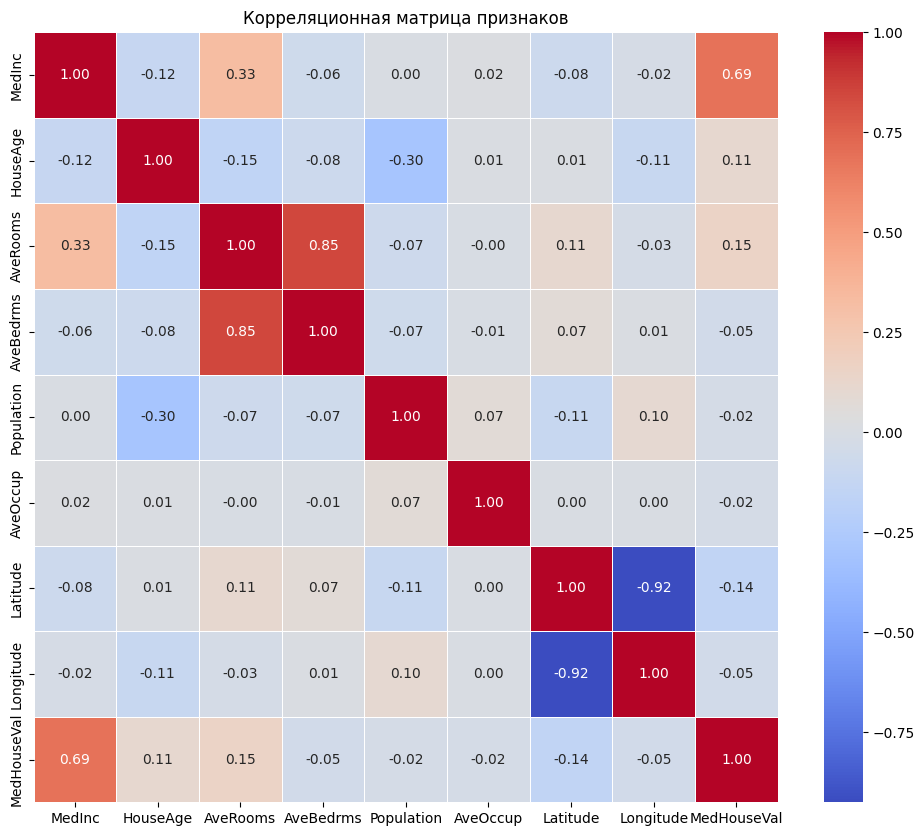

In [182]:
# Корреляционная матрица
correlation_matrix = dataframe.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Корреляционная матрица признаков')
plt.show()

### Выводы из корреляционной матрицы:

1.  **Корреляция с целевой переменной `MedHouseVal`:**
    *   `MedInc` (медианный доход) имеет самую сильную положительную корреляцию с `MedHouseVal` (около 0.69), что указывает на его значительное влияние на стоимость жилья.
    *   Остальные признаки имеют относительно слабую линейную корреляцию с целевой переменной.
2.  **Мультиколлинеарность между признаками:**
    *   Наблюдается очень сильная положительная корреляция между `AveRooms` (среднее количество комнат) и `AveBedrms` (среднее количество спален) — около 0.85. Эти признаки измеряют схожие аспекты размера дома и могут быть избыточными.
    *   Также существует очень сильная отрицательная корреляция между `Latitude` (широта) и `Longitude` (долгота) — около -0.92. Это ожидаемо, так как они описывают географическое положение.

### Решение по удалению признаков:

Принимая во внимание высокую корреляцию между `AveRooms` и `AveBedrms`, а также относительно низкую корреляцию `AveBedrms` с целевой переменной (`-0.05`), целесообразно удалить признак `AveBedrms` для уменьшения мультиколлинеарности в модели без существенной потери предсказательной силы. В то время как `Latitude` и `Longitude` сильно коррелированы, оба они критически важны для определения местоположения недвижимости, и их удаление может привести к потере важной информации о региональных различиях в ценах.

In [183]:
# Удаление'AveBedrms'
X_cleaned = X.drop('AveBedrms', axis=1)

# Заново разбиваем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size=0.2, random_state=42)

print("Признак 'AveBedrms' удален. Данные переразбиты на обучающую и тестовую выборки.")
print(f"Новое количество признаков в X_train: {X_train.shape[1]}")

Признак 'AveBedrms' удален. Данные переразбиты на обучающую и тестовую выборки.
Новое количество признаков в X_train: 7


In [184]:
# Модель линейной регрессии и метрики на преобразованных данных
second_model = fit_model(X_train, y_train, X_test, y_test)

Метрики на обучающем множестве:
  MSE: 0.54
  RMSE: 0.73
  R2: 0.60

Метрики на тестовом множестве:
  MSE: 0.55
  RMSE: 0.74
  R2: 0.58


### Исследование выбросов в признаках

Давайте визуализируем каждый признак с помощью ящиков с усами (box plots), чтобы выявить потенциальные выбросы.

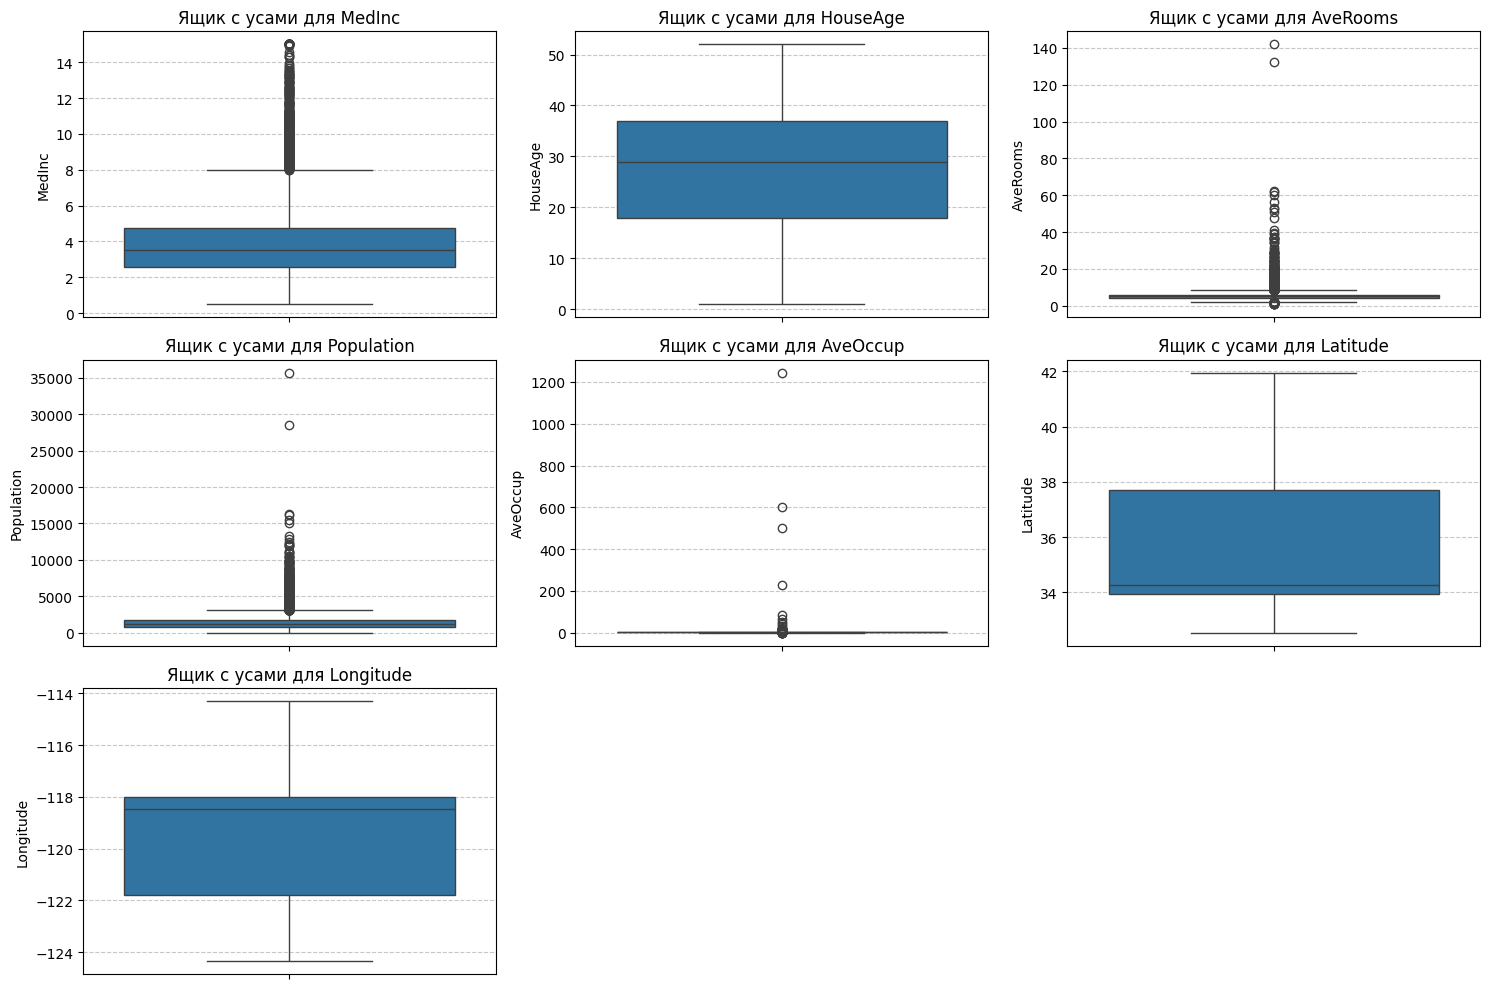

In [185]:
# Визуализация выбросов для каждого признака в X_cleaned

plt.figure(figsize=(15, 10))
for i, column in enumerate(X_cleaned.columns):
    plt.subplot(3, 3, i + 1) # Предполагая 7-8 признаков, используем 3x3 сетку
    sns.boxplot(y=X_cleaned[column])
    plt.title(f'Ящик с усами для {column}')
    plt.ylabel(column)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [186]:
# Функция для удаления выбросов с использованием межквартильного размаха IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_cleaned

# Применяем удаление выбросов для признаков с заметными выбросами
X_cleaned_no_outliers = X_cleaned.copy()

# Поскольку y_cleaned_no_outliers зависит от индексов X_cleaned_no_outliers,
# необходимо создать y_cleaned_no_outliers из оригинального y, используя отфильтрованные индексы.
# Сначала объединим X_cleaned и y в один DataFrame, чтобы обеспечить согласованное удаление строк.

df_combined = pd.concat([X_cleaned, y], axis=1)

# Применяем удаление выбросов для признаков с заметными выбросами на объединенном DataFrame
for col in ['MedInc', 'AveRooms', 'Population', 'AveOccup']:
    df_combined = remove_outliers_iqr(df_combined, col)

# Теперь разделяем обратно на X и y
X_cleaned_no_outliers = df_combined.drop('MedHouseVal', axis=1).reset_index(drop=True)
y_cleaned_no_outliers = df_combined['MedHouseVal'].reset_index(drop=True)

print(f"Общее количество строк после удаления выбросов: {X_cleaned_no_outliers.shape[0]}")

# Заново разбиваем данные на обучающую и тестовую выборки после удаления выбросов
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(
    X_cleaned_no_outliers, y_cleaned_no_outliers, test_size=0.2, random_state=42)

print("Данные переразбиты на обучающую и тестовую выборки после удаления выбросов.")
print(f"Размер обучающего множества (X_train_cleaned): {X_train_cleaned.shape}")
print(f"Размер тестового множества (X_test_cleaned): {X_test_cleaned.shape}")

# Новая модель на данных без выбросов
print("\nОбучение модели на данных без выбросов:")
third_model = fit_model(X_train_cleaned, y_train_cleaned, X_test_cleaned, y_test_cleaned)

Общее количество строк после удаления выбросов: 17797
Данные переразбиты на обучающую и тестовую выборки после удаления выбросов.
Размер обучающего множества (X_train_cleaned): (14237, 7)
Размер тестового множества (X_test_cleaned): (3560, 7)

Обучение модели на данных без выбросов:
Метрики на обучающем множестве:
  MSE: 0.44
  RMSE: 0.66
  R2: 0.62

Метрики на тестовом множестве:
  MSE: 0.45
  RMSE: 0.67
  R2: 0.62


### Математическое преобразование признаков

Применим логарифмическое преобразование к признакам `MedInc` и `Population`, так как они имеют сильно скошенные распределения. Для `AveRooms` и `AveOccup` используем квадратный корень, чтобы сделать их распределение более нормальным. Эти преобразования направлены на нормализацию распределений признаков, что может улучшить производительность линейных моделей, так как они лучше соответствуют предположениям модели.

In [187]:
X_transformed = X_cleaned_no_outliers.copy()

# Логарифмическое преобразование для MedInc и Population
X_transformed['MedInc_log'] = np.log1p(X_transformed['MedInc'])
X_transformed['Population_log'] = np.log1p(X_transformed['Population'])

# Преобразование квадратного корня для AveRooms и AveOccup
X_transformed['AveRooms_sqrt'] = np.sqrt(X_transformed['AveRooms'])
X_transformed['AveOccup_sqrt'] = np.sqrt(X_transformed['AveOccup'])

# Удаление оригинальных признаков
X_transformed = X_transformed.drop(columns=['MedInc', 'Population', 'AveRooms', 'AveOccup'])

print("Признаки успешно преобразованы и добавлены в DataFrame.")
display(X_transformed.head())

Признаки успешно преобразованы и добавлены в DataFrame.


,HouseAge,Latitude,Longitude,MedInc_log,Population_log,AveRooms_sqrt,AveOccup_sqrt
0,52.0,37.85,-122.25,1.893579,6.326149,2.411919,1.596228
1,52.0,37.85,-122.25,1.578195,6.338594,2.506363,1.476979
2,52.0,37.85,-122.25,1.616771,6.025866,2.182122,1.462838
3,52.0,37.84,-122.25,1.538822,6.998510,2.220790,1.458905
4,52.0,37.84,-122.25,1.415853,7.054450,2.190326,1.337256


In [188]:
# Разбивка преобразованных данных
X_train_transformed, X_test_transformed, y_train_transformed, y_test_transformed = train_test_split(
    X_transformed, y_cleaned_no_outliers, test_size=0.2, random_state=42
)

print("Данные переразбиты на обучающую и тестовую выборки после преобразования признаков.")
print(f"Размер обучающего множества (X_train_transformed): {X_train_transformed.shape}")
print(f"Размер тестового множества (X_test_transformed): {X_test_transformed.shape}")

# Обучаем новую модель на данных с преобразованными признаками
print("\nОбучение модели на данных с преобразованными признаками:")
fourth_model = fit_model(X_train_transformed, y_train_transformed, X_test_transformed, y_test_transformed)

Данные переразбиты на обучающую и тестовую выборки после преобразования признаков.
Размер обучающего множества (X_train_transformed): (14237, 7)
Размер тестового множества (X_test_transformed): (3560, 7)

Обучение модели на данных с преобразованными признаками:
Метрики на обучающем множестве:
  MSE: 0.46
  RMSE: 0.68
  R2: 0.60

Метрики на тестовом множестве:
  MSE: 0.48
  RMSE: 0.69
  R2: 0.60


## Выводы по проделанной работе

### Краткое описание преобразований данных:

1.  **Удаление признаков (Feature Engineering):** На основе анализа корреляционной матрицы был удален признак `AveBedrms` из-за высокой мультиколлинеарности с `AveRooms` и низкой корреляции с целевой переменной.
2.  **Удаление выбросов:** Были проанализированы выбросы в оставшихся признаках (`MedInc`, `AveRooms`, `Population`, `AveOccup`) и удалены с использованием метода IQR.
4.  **Математические преобразования признаков:** Для некоторых признаков были применены математические преобразования для нормализации их распределений, что может улучшить работу линейных моделей:
    *   `MedInc` и `Population` были логарифмически преобразованы (использован `np.log1p`).
    *   `AveRooms` и `AveOccup` были преобразованы с помощью квадратного корня (`np.sqrt`).

### Сравнение метрик всех моделей:

Для сравнения будем использовать метрики на **тестовой выборке**, так как они лучше отражают обобщающую способность модели.

| Модель                                                      | RMSE (Тест) | R2 (Тест) | Признаки, на которых проводилось обучение (с преобразованиями)                                                                                                              |
| :---------------------------------------------------------- | :---------- | :-------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Первая модель** (базовая)                                 | 0.75        | 0.58      | Все исходные признаки (8 признаков)                                                                                                                                         |
| **Вторая модель** (после удаления `AveBedrms`)              | 0.74        | 0.58      | 7 признаков (без `AveBedrms`)                                                                                                                                               |
| **Третья модель** (без `AveBedrms` и с удалением выбросов)  | **0.67**    | **0.62**  | 7 признаков (без `AveBedrms`), с удаленными выбросами из `MedInc`, `AveRooms`, `Population`, `AveOccup` и `MedHouseVal`.                                                    |
| **Четвертая модель** (с преобразованными признаками)        | 0.69        | 0.60      | 7 признаков (без `AveBedrms`, с удаленными выбросами), плюс `MedInc_log`, `Population_log`, `AveRooms_sqrt`, `AveOccup_sqrt` вместо исходных (всего 7 признаков). |


### Мнение о выполнении задачи:

Модели справились с поставленной задачей в достаточной мере. Улучшение метрик было достигнуто, что соответствует цели домашнего задания:

*   **RMSE** снизился с 0.75 (базовая модель) до **0.67** (модель с удаленными выбросами), что является заметным улучшением. Это означает, что модель стала делать в среднем более точные прогнозы, так как ошибка уменьшилась.
*   **R2** увеличился с 0.58 (базовая модель) до **0.62** (модель с удаленными выбросами). Это свидетельствует о том, что модель объясняет на 4% больше дисперсии целевой переменной, что также является положительным результатом.

Наилучшие метрики были достигнуты после удаления выбросов из признаков и целевой переменной (Третья модель). Последующие математические преобразования признаков (Четвертая модель) привели к небольшому ухудшению метрик (RMSE вырос, R2 снизился) по сравнению с Третьей моделью, что может указывать на то, что для данного набора данных или конкретных преобразований они не принесли дополнительной пользы или даже внесли некоторый шум. Однако, они все равно показали лучшие результаты, чем первые две модели.

В целом, проделанная работа по очистке данных и отбору признаков позволила построить более эффективную модель для прогнозирования стоимости жилья.